# memo

#  `__main__`

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================================
# Spacetime Metric
# ============================================================================
# Linearized Schwarzschild
def g_xx(x,y):
    d = np.sqrt(x**2 + y**2)
    if (d > R):
        return 1 + 2*M * (x**2 / d**3)
    else:
        return 1 + M/R * (3 - d**2/R**2) * (x**2 / d**2)

# ============================================================================
# Embedding PDE
# ============================================================================
# sign picker
def pick_partialx_sign(x):
    sign = None
    if x >= 0:
        sign = 1
    elif x < 0:
        sign = -1
    return sign
# Embedding PDE
def partial_x_Z(x, y):
    sign = pick_partialx_sign(x)
    return sign * np.sqrt(g_xx(x, y) - 1)
def boundary_condition(x, y):
    d = np.sqrt(x**2 + y**2)
    return 2*np.sqrt(d - 1)

# ============================================================================
# values for the system
# ============================================================================
M = 1
R = 10*M
n_steps_in_y = 100

# ============================================================================
# Initial value (boundary)
# ============================================================================
# grid size
x_range = [-100*M , 100*M]
y_range = [-100*M , 100*M]
# boundary at x = -100
y_axis = np.linspace(y_range[0], y_range[1], n_steps_in_y)
y_boundary = boundary_condition(x_range[0], y_axis)

# ============================================================================
# solve_ivp method
# ============================================================================
sol = solve_ivp(partial_x_Z, x_range, y_boundary, method='RK45')

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# value check

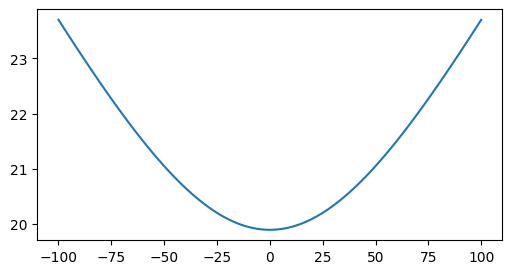

In [58]:
# 1D plot check
def plot_1d(tested_sequence, axis_range):
    npoint = tested_sequence.size
    axis = np.linspace(axis_range[0], axis_range[1], npoint)
    
    fig, ax = plt.subplots(figsize=(6,3))
    ax.plot(axis, tested_sequence)

plot_1d(y_boundary, x_range)

# test solve_ivp

In [50]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

def dy_dt(t, y):
    return 2*t

t0, tf = 0, 10
t_span = (t0, tf)

initial_state = [4, 10, 100]
y0 = initial_state


bunch = solve_ivp(dy_dt, t_span, y0, method='RK45')
print(bunch)

print(f'\n\nshape of y (adaptive): {bunch.y.shape}\n\n')


'''
# ========================
# plotting
# ========================
# plotting function
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(10, 6))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    # from matplotlib example (modified)
    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)
    # ax_3d.set_zlim(bottom=0)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)} r_s')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)} r_s')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None
# y
plot_3d_and_slice(bunch.y, 'y')
'''

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-04  1.100e-03  1.110e-02  1.111e-01
             1.111e+00  1.000e+01]
        y: [[ 4.000e+00  4.000e+00 ...  5.235e+00  1.040e+02]
            [ 1.000e+01  1.000e+01 ...  1.123e+01  1.100e+02]
            [ 1.000e+02  1.000e+02 ...  1.012e+02  2.000e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 38
     njev: 0
      nlu: 0


shape of y (adaptive): (3, 7)




"\n# ========================\n# plotting\n# ========================\n# plotting function\ndef plot_3d_and_slice(surface, surface_name):\n    num_slices = 4\n\n    fig= plt.figure(figsize=(10, 6))\n    ax_3d = fig.add_subplot(221, projection='3d')\n    ax_slicex = fig.add_subplot(223)\n    ax_slicey = fig.add_subplot(224)\n\n    # from matplotlib example (modified)\n    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)\n    ax_3d.zaxis.set_major_formatter('{x:.02f}')\n    fig.colorbar(surf, shrink=0.5, aspect=5)\n    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)\n    # ax_3d.set_zlim(bottom=0)\n\n    color = ['b', 'g', 'y' , 'r']\n    while len(color) < num_slices:\n        color.append['r']\n    \n    for i in range(num_slices):\n         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)} r_s')\n         ax_slicex.set(xlabel='x', ylabel=surface_name, t

# explanations

somthing

# ideas
- after solving with $\frac{\partial Z}{\partial x}$ equation, solve it with $\frac{\partial Z}{\partial y}$ equation. they should return the same surface